# T09 — ARMA Model — Book: CH06

**Methodology**: Marco Peixeiro, *Time Series Forecasting in Python*, Chapter 6.

### Book-mandated steps:
1. ADF stationarity test → confirm d=0
2. ACF + PACF plots
3. `optimize_ARMA` → select by lowest AIC (SARIMAX)
4. Fit best model → Ljung-Box residuals
5. `rolling_forecast_engine` → walk-forward validation
6. Full test evaluation

In [13]:
import sys, os
from pathlib import Path
from functools import partial
from itertools import product

ROOT = Path(os.getcwd()).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Book imports — exactly as CH06 uses them
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

from src.models.classical import (
    build_pca_health_index, compute_failure_threshold,
    run_stationarity_report, smooth_series,
    select_best_arma_order, _get_representative_engine,
    check_residuals, rolling_forecast_engine,
    predict_rul_arma, predict_dataset, _get_representative_engine, validate_model_rolling
)
from src.evaluation.metrics import evaluate

PROC_DIR    = ROOT / "data" / "processed"
SENSOR_COLS = [f"s{i}" for i in [2,3,4,7,8,9,11,12,13,14,15,17,20,21]]

## 1. Load data + build health_index

In [14]:
train = pd.read_csv(PROC_DIR / "train_features.csv")
test  = pd.read_csv(PROC_DIR / "test_features.csv")
train, test = build_pca_health_index(train, test, SENSOR_COLS, n_components=2)

THRESHOLD = compute_failure_threshold(train, end_of_life_rul=5, quantile=0.05)
print(f"Failure threshold: {THRESHOLD:.4f}")

health_index R2 with RUL (post-monotone): -5.188  (target: > 0.3)
Failure threshold: 1.6850


In [15]:
# In any notebook, after build_pca_health_index
# This tells you EXACTLY what threshold value will work

hi_min  = train["health_index"].min()
hi_max  = train["health_index"].max()
hi_mean = train["health_index"].mean()
print(f"health_index range: [{hi_min:.3f}, {hi_max:.3f}]  mean={hi_mean:.3f}")

# Check what threshold each quantile gives
print("\nThreshold candidates:")
for q in [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
    t = compute_failure_threshold(train, end_of_life_rul=5, quantile=q)
    # Count test engines whose health_index ever reaches this threshold
    reachable = 0
    for _, g in test.groupby("engine_id"):
        if g["health_index"].max() >= t:
            reachable += 1
    pct = 100 * reachable / test["engine_id"].nunique()
    print(f"  q={q:.2f} → threshold={t:.3f}  |  {reachable}/{test['engine_id'].nunique()} "
          f"test engines reach it ({pct:.0f}%)")

health_index range: [-1.597, 4.402]  mean=-0.000

Threshold candidates:
  q=0.05 → threshold=1.685  |  22/248 test engines reach it (9%)
  q=0.10 → threshold=1.747  |  20/248 test engines reach it (8%)
  q=0.20 → threshold=1.840  |  17/248 test engines reach it (7%)
  q=0.30 → threshold=1.927  |  17/248 test engines reach it (7%)
  q=0.50 → threshold=2.166  |  13/248 test engines reach it (5%)
  q=0.70 → threshold=3.363  |  0/248 test engines reach it (0%)
  q=0.90 → threshold=3.707  |  0/248 test engines reach it (0%)


health_index vs RUL R2: -5.188


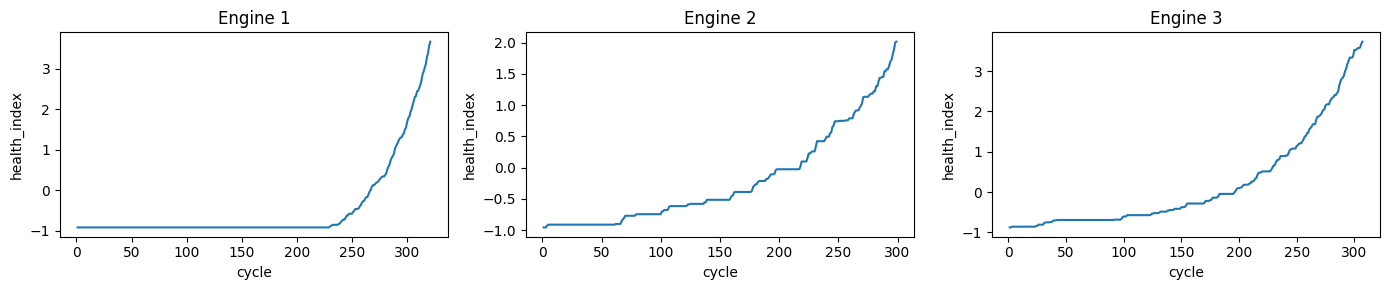

In [16]:
# Sanity check: health_index should increase as RUL decreases
from sklearn.metrics import r2_score
r2 = r2_score(-train["RUL"].values, train["health_index"].values)
print(f"health_index vs RUL R2: {r2:.3f}")
# If R2 < 0.1 → health_index is not tracking degradation → PCA sign flip failed
# If R2 > 0.3 → good signal

# Plot a few engines to visually confirm health_index rises over time
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, eid in zip(axes, train["engine_id"].unique()[:3]):
    g = train[train["engine_id"] == eid].sort_values("cycle")
    ax.plot(g["cycle"], g["health_index"])
    ax.set_title(f"Engine {eid}")
    ax.set_xlabel("cycle"); ax.set_ylabel("health_index")
plt.tight_layout(); plt.show()
# Should show rising trend — if flat or noisy → PCA is not capturing degradation

## 2. Stationarity check — ADF (CH06)

ARMA requires stationary series (d=0). ADF on health_index confirms this.

In [17]:
# Stratified ADF across all 4 subsets
stationarity_df = run_stationarity_report(train, n_engines=10)
# ARMA requires d=0 — confirm here


Stationarity Report (ADF test per sampled engine):
engine_id   level_p     diff1_p     rec_d
--------------------------------------------
1           0.9958      1.0         2.0
2           1.0         0.9267      2.0
3           1.0         0.8719      2.0
4           1.0         0.6973      2.0
5           1.0         1.0         2.0
6           1.0         0.9953      2.0
7           0.9991      0.0007      1.0
8           1.0         0.9014      2.0
9           1.0         0.9697      2.0
10          0.9989      0.9985      2.0

d distribution: {2: 9, 1: 1}
→ recommended d = 2  (modal across 10 sampled engines)



d=0 (already stationary)   : 0 engines
d=1 (1 difference needed)  : 1 engines
d=2 (2 differences needed) : 9 engines

→ Use d = 2 for ARMA


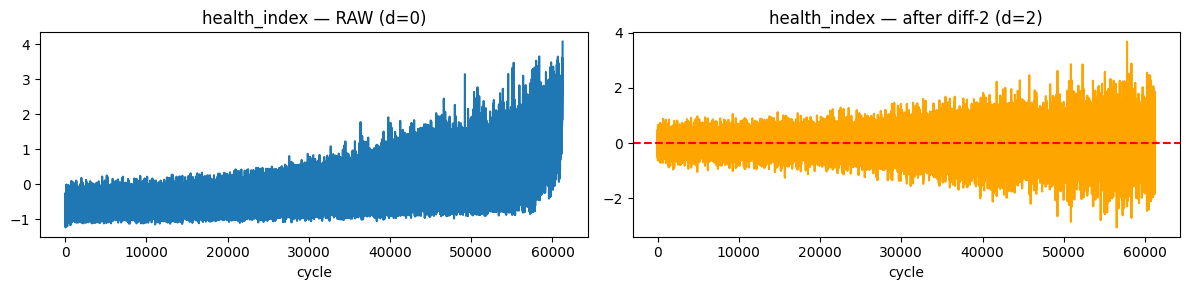

In [18]:
# ── After running stationarity_df = run_stationarity_report(...) ──────

# 1. See d distribution across all engines
d_counts = stationarity_df["recommended_d"].value_counts().sort_index()
print("\nd=0 (already stationary)   :", d_counts.get(0, 0), "engines")
print("d=1 (1 difference needed)  :", d_counts.get(1, 0), "engines")
print("d=2 (2 differences needed) :", d_counts.get(2, 0), "engines")

# 2. Extract the modal d — this is what you pass to ARIMA
MODAL_D = int(stationarity_df["recommended_d"].mode()[0])
print(f"\n→ Use d = {MODAL_D} for ARMA")

# 3. Visual: compare raw vs differenced for one engine
raw  = train.sort_values("cycle").health_index.values
smth = smooth_series(raw, window=5)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(smth)
axes[0].set_title("health_index — RAW (d=0)")
axes[0].set_xlabel("cycle")

diff1 = np.diff(smth, n=1)
axes[1].plot(diff1, color="orange")
axes[1].axhline(0, color="red", ls="--")
axes[1].set_title(f"health_index — after diff-{MODAL_D} (d={MODAL_D})")
axes[1].set_xlabel("cycle")

plt.tight_layout()
plt.show()
# Raw: should show a clear downward trend (non-stationary)
# After diff-1: should hover around 0 with no trend (stationary)

## 3. ACF and PACF plots (CH06)

ACF tail-off + PACF tail-off = ARMA(p,q) signature.

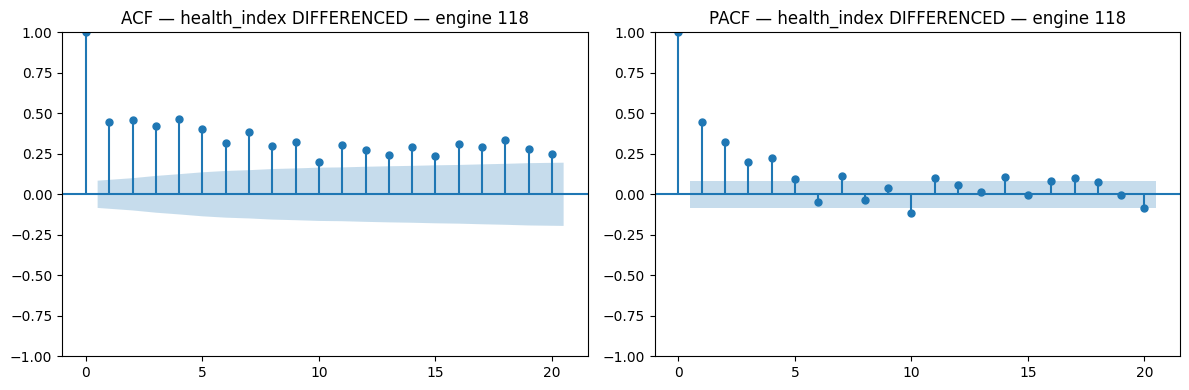

ACF tail-off + PACF tail-off => ARMA(p,q) model


In [19]:
rep_eid, rep_smth = _get_representative_engine(train)
smth_diff = np.diff(rep_smth, n=1)
from src.models.classical import plot_acf_pacf
plot_acf_pacf(smth_diff, lags=20, title=f"health_index DIFFERENCED — engine {rep_eid}")
print("ACF tail-off + PACF tail-off => ARMA(p,q) model")

## 4. `optimize_ARMA` — select (p,q) by AIC (CH06 core step)

Book sorts all (p,q) combos by AIC ascending. Lowest AIC wins.

In [20]:
BEST_P, BEST_Q = select_best_arma_order(train, d=MODAL_D, n_engines=15)

  engine 1: best (p,q)=(2, 1)  (AIC=-1717.3)
  engine 2: best (p,q)=(1, 1)  (AIC=-1514.52)
  engine 3: best (p,q)=(1, 1)  (AIC=-1456.44)
  engine 4: best (p,q)=(2, 3)  (AIC=-1326.35)
  engine 5: best (p,q)=(3, 2)  (AIC=-895.11)
  engine 6: best (p,q)=(2, 1)  (AIC=-1638.74)
  engine 7: best (p,q)=(3, 3)  (AIC=-1128.36)
  engine 8: best (p,q)=(3, 1)  (AIC=-1144.73)
  engine 9: best (p,q)=(1, 1)  (AIC=-1662.76)
  engine 10: best (p,q)=(1, 2)  (AIC=-1820.47)
  engine 11: best (p,q)=(1, 1)  (AIC=-1596.33)
  engine 12: best (p,q)=(3, 2)  (AIC=-1460.38)
  engine 13: best (p,q)=(2, 1)  (AIC=-1259.72)
  engine 14: best (p,q)=(2, 3)  (AIC=-1198.12)
  engine 15: best (p,q)=(3, 3)  (AIC=-936.93)

→ Modal best ARMA order: (1,1)  (from 15 engines, freq=[((1, 1), 4), ((2, 1), 3), ((2, 3), 2), ((3, 2), 2), ((3, 3), 2)])


## 5. Fit best ARMA + Ljung-Box (CH06 requirement)

In [21]:
rep_eid, rep_smth = _get_representative_engine(train)
# WHY: no manual diff — SARIMAX handles d internally, matching predict_rul_arma
model_fit = SARIMAX(rep_smth, order=(BEST_P, MODAL_D, BEST_Q),
                    simple_differencing=False).fit(disp=False)
print(model_fit.summary())
lb_result = check_residuals(model_fit.resid, model_name=f"ARMA({BEST_P},{BEST_Q})")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  543
Model:               SARIMAX(1, 2, 1)   Log Likelihood                1459.052
Date:                Mon, 27 Apr 2026   AIC                          -2912.104
Time:                        14:37:26   BIC                          -2899.223
Sample:                             0   HQIC                         -2907.067
                                - 543                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0376      0.028      1.360      0.174      -0.017       0.092
ma.L1         -0.9141      0.012    -77.719      0.000      -0.937      -0.891
sigma2         0.0003   8.81e-06     30.074      0.0

## 6. Rolling forecast — walk-forward validation (CH06 pattern)

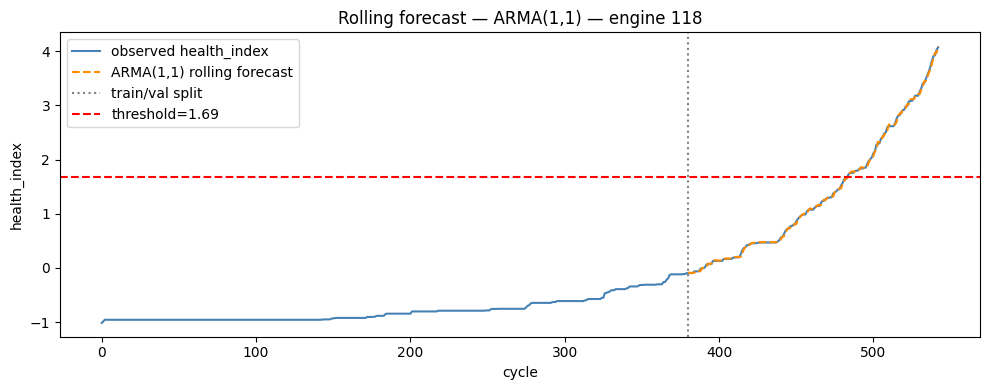

Rolling forecast RMSE: 0.0273


In [22]:
rep_eid, rep_smth = _get_representative_engine(train)
TRAIN_LEN = int(len(rep_smth) * 0.7)
WINDOW    = 1

pred_arma  = rolling_forecast_engine(
    series=rep_smth, train_len=TRAIN_LEN,
    order=(BEST_P, MODAL_D, BEST_Q),
    window=WINDOW,
)

actual_val = rep_smth[TRAIN_LEN: TRAIN_LEN + len(pred_arma)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rep_smth, color="steelblue", label="observed health_index")
ax.plot(range(TRAIN_LEN, TRAIN_LEN + len(pred_arma)), pred_arma,
        color="darkorange", ls="--", label=f"ARMA({BEST_P},{BEST_Q}) rolling forecast")
ax.axvline(TRAIN_LEN, color="gray", ls=":", label="train/val split")
ax.axhline(THRESHOLD, color="red", ls="--", label=f"threshold={THRESHOLD:.2f}")
ax.set_xlabel("cycle"); ax.set_ylabel("health_index")
ax.set_title(f"Rolling forecast — ARMA({BEST_P},{BEST_Q}) — engine {rep_eid}")
ax.legend(); plt.tight_layout(); plt.show()

rmse_roll = float(np.sqrt(np.mean((actual_val - pred_arma)**2)))
print(f"Rolling forecast RMSE: {rmse_roll:.4f}")

## 7. Full test-set evaluation

In [23]:
predict_fn = partial(predict_rul_arma, p=BEST_P, q=BEST_Q, d=MODAL_D)

# Final report must still use all 248:
y_true, y_pred = predict_dataset(test, predict_fn, THRESHOLD, verbose_engines=True )
evaluate(y_true, y_pred, model_name=f"ARMA({BEST_P},{BEST_Q}) — full 248")

    engine    1  true=  22.0  pred=   9.7  err=-12.3
    engine    2  true=  39.0  pred=  22.9  err=-16.1
    engine    3  true= 107.0  pred= 110.0  err=+3.0 [FALLBACK]
    engine    4  true=  75.0  pred= 110.0  err=+35.0 [FALLBACK]
    engine    5  true= 125.0  pred= 110.0  err=-15.0 [FALLBACK]
    engine    6  true=  78.0  pred=  97.7  err=+19.7
    engine    7  true=  94.0  pred=  88.0  err=-6.0
    engine    8  true=  14.0  pred=   3.5  err=-10.5
    engine    9  true=  99.0  pred= 125.0  err=+26.0
    engine   10  true= 125.0  pred= 125.0  err=+0.0
    engine   11  true= 125.0  pred= 110.0  err=-15.0 [FALLBACK]
    engine   12  true=   7.0  pred=   2.6  err=-4.4
    engine   13  true=  71.0  pred= 117.9  err=+46.9
    engine   14  true= 105.0  pred= 110.0  err=+5.0 [FALLBACK]
    engine   15  true=  12.0  pred=   2.6  err=-9.4
    engine   16  true= 125.0  pred= 110.0  err=-15.0 [FALLBACK]
    engine   17  true= 125.0  pred= 110.0  err=-15.0 [FALLBACK]
    engine   18  true= 104.0

{'rmse': 26.28690528869629,
 'nasa_score': 16058.6005859375,
 'nasa_score_mean': 64.75242171748992,
 'r2_score': 0.6259559392929077,
 'bias': -1.7469357252120972}

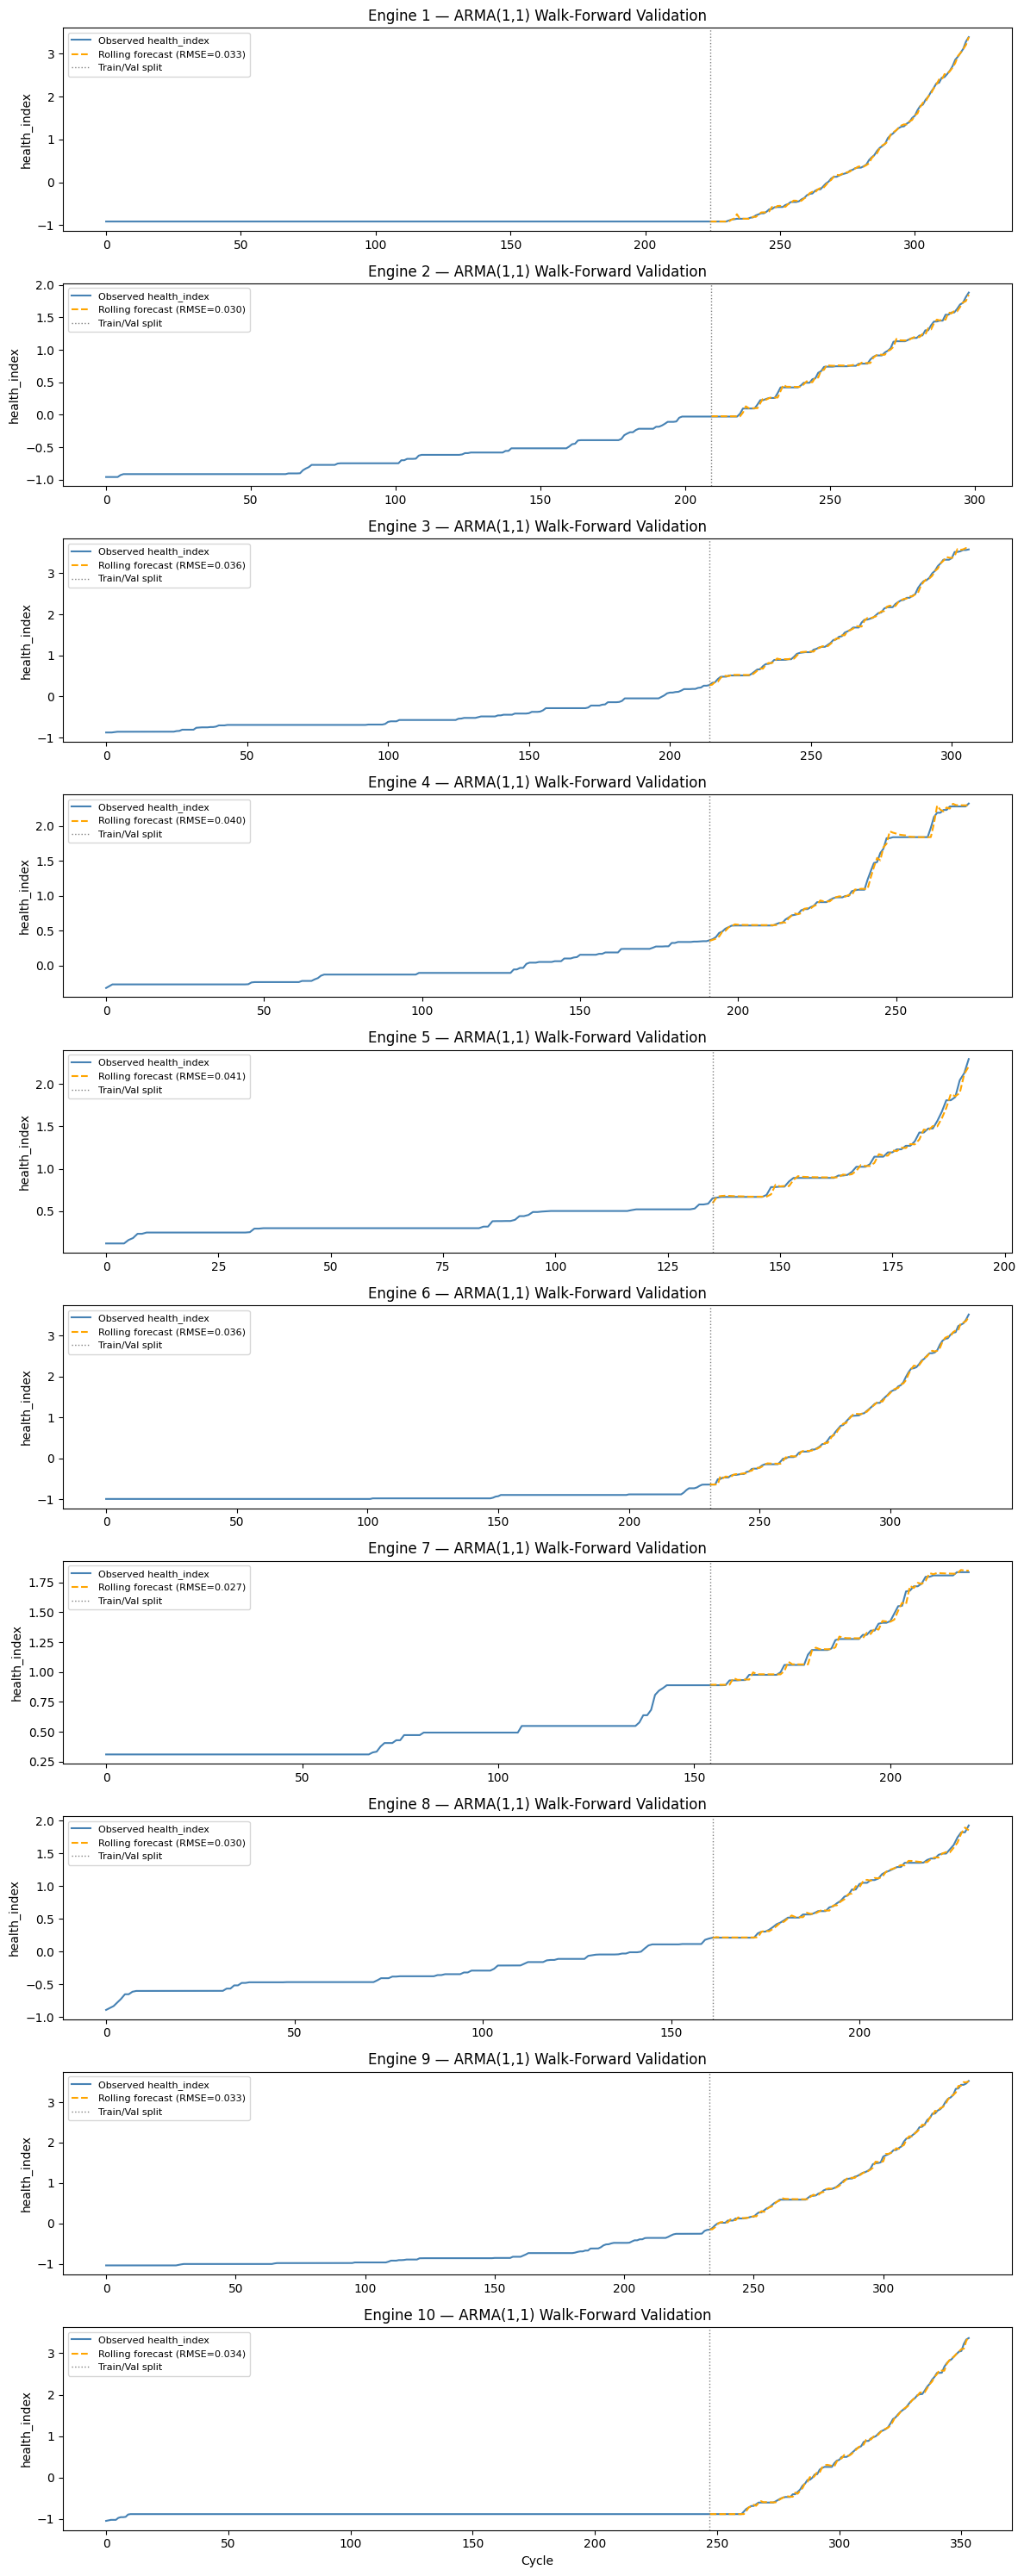


ARMA(1,1) Walk-Forward Validation Summary
Engines validated : 10
Mean RMSE         : 0.0340
Std RMSE          : 0.0043
Best engine RMSE  : 0.0267
Worst engine RMSE : 0.0410


In [24]:
val_rmse = validate_model_rolling(
    train      = train,
    order      = (BEST_P, MODAL_D, BEST_Q),
    n_engines  = 10,
    model_name = f"ARMA({BEST_P},{BEST_Q})"
)